In [54]:
import pandas as pd

metric_paths = [
    '/data/all_checkpoints/PP_mistral7b_string+graph_gnn_freeze_0111/lightning_logs/version_2/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_string+graph_0111/lightning_logs/version_1/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_modality_random_0111/lightning_logs/version_1/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_string+graph_llava_projector_0111/lightning_logs/version_0/metrics.csv'
    ]

simdpo_1 = [
    '/data/all_checkpoints/PP_mistral7b_modality_random_mdpo_0111/lightning_logs/version_1/metrics.csv',
    '/data/all_checkpoints/PP_mistral7b_modality_random_mdpo_0111/lightning_logs/version_2/metrics.csv',
]

simpo1_metrics = [pd.read_csv(metric_path) for metric_path in simdpo_1]
# concat simpo1_metrics
simpo1_metrics = pd.concat(simpo1_metrics)


simdpo_2 = [
    '/data/all_checkpoints/PP_mistral7b_modality_random_mdpo_simpo0.5_0111/lightning_logs/version_1/metrics.csv',
]
simpo2_metrics = [pd.read_csv(metric_path) for metric_path in simdpo_2]
# concat simpo2_metrics
simpo2_metrics = pd.concat(simpo2_metrics)


labels = [
    'string+graph / gnn freezing',
    'string+graph / gnn tuning',
    'random / gnn tuning',
    'random / gnn tuning / mlp projector',
    'random / gnn tuning / simpo',
    'random / gnn tuning / simpo0.5'
]
metrics = [pd.read_csv(metric_path) for metric_path in metric_paths]
metrics.append(simpo1_metrics)
metrics.append(simpo2_metrics)


In [55]:
simpo2_metrics[column].index

RangeIndex(start=0, stop=45, step=1)

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

def draw_line_plot(
        ax, df, column, label, xlabel='Val Epochs',
        y_lim=0.03, x_lim=None
        ):
    y = df[column].dropna()
    x = y.index
    ax.plot(x, y, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(column)
    ax.set_ylim(0, y_lim)
    ax.legend()
    return ax

def draw_line_plots_for_column(column, dfs, labels, y_lim=0.03):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111)
    for i in range(len(dfs)):
        draw_line_plot(
            ax, dfs[i], column, labels[i], y_lim=y_lim
        )
    return ax

In [61]:
columns = [
    ('val/qm9_homo_lumo_gap/mae', 0.03),
    ('val/smol-property_prediction-esol/mae', 4),
    ('val/smol-property_prediction-lipo/mae', 2.5),
    ('val/bace/roc_auc', 1.0),
    ('val/smol-property_prediction-hiv/roc_auc', 1.0),
    ('val/smol-property_prediction-clintox/roc_auc', 1.0),
    ('val/smol-property_prediction-bbbp/roc_auc', 1.0)
]


In [58]:
len(metrics), len(labels)

(6, 6)

In [ ]:
draw_line_plots_for_column('val/graph_attn_score', metrics, labels, 1)

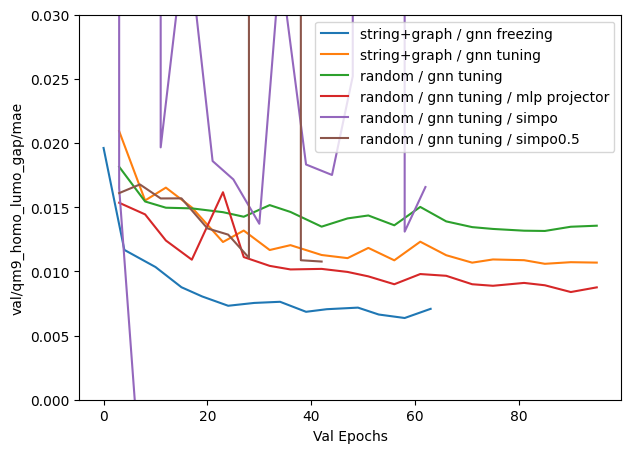

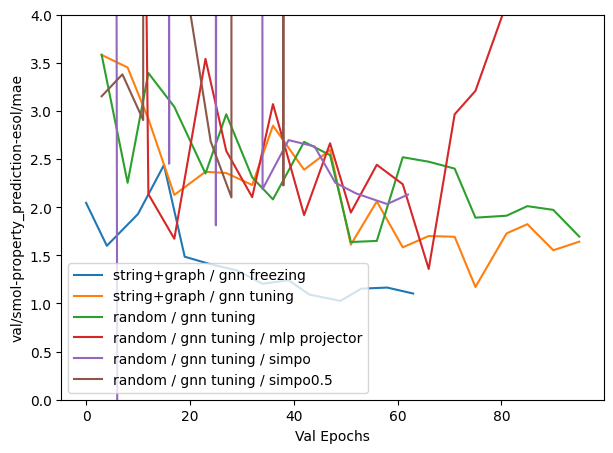

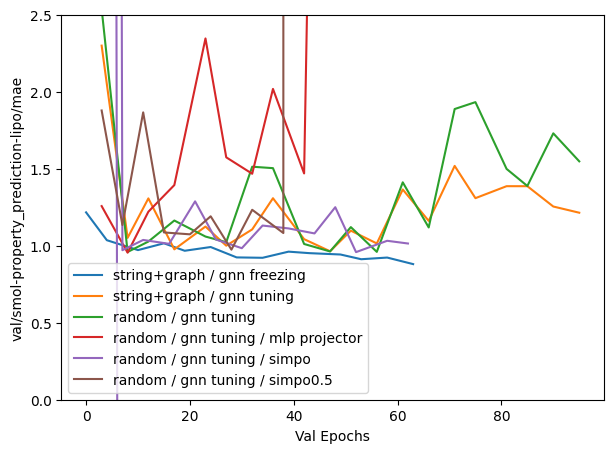

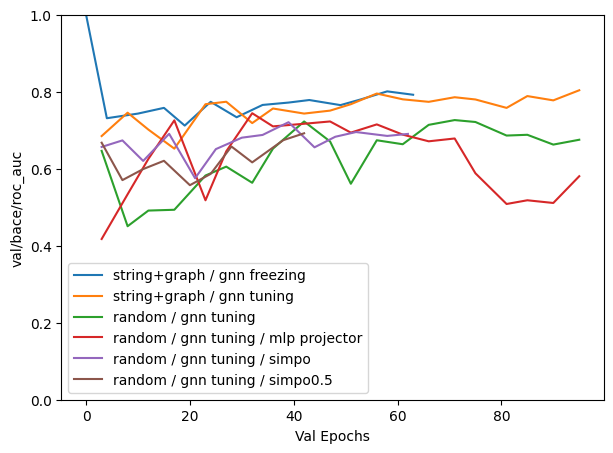

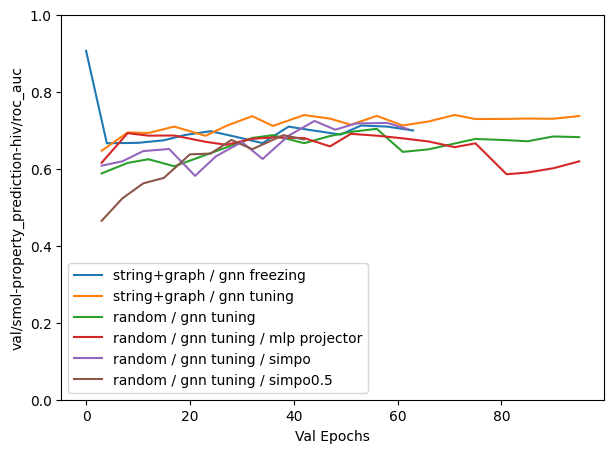

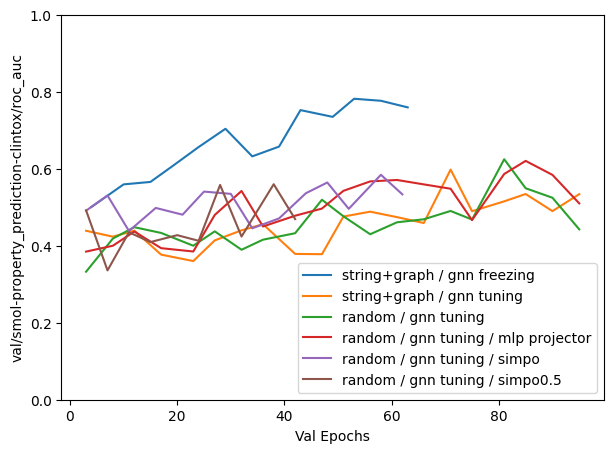

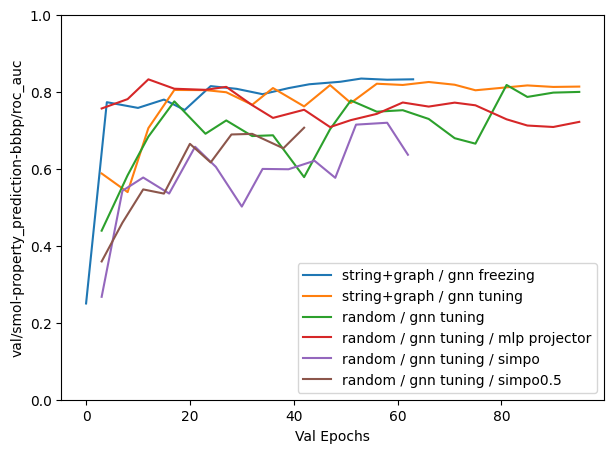

In [62]:
for i in range(len(columns)):
    draw_line_plots_for_column(columns[i][0], metrics, labels, columns[i][1])

<Axes: xlabel='Val Epochs', ylabel='val/qm9_homo_lumo_gap/mae'>

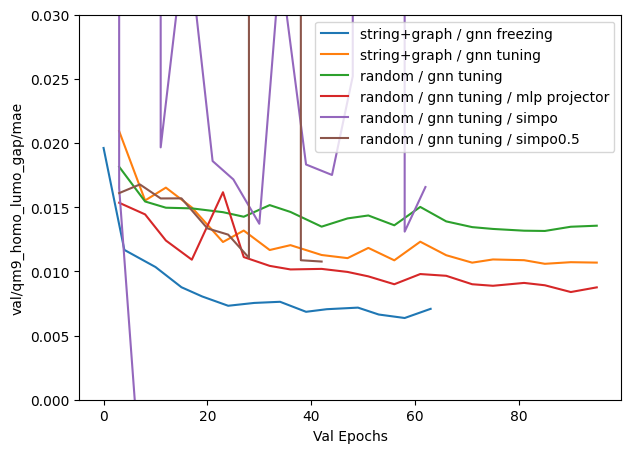

In [59]:
draw_line_plots_for_column(column, metrics, labels)